# Project Name: 4-Weeks Country-Category Market Segmentation


## 📝 Project Info

#### 🏭 Industry  
- E-commerce & Marketing  

#### 🌐 Domain  
- Lifestyle & Consumer Themes  


## 📂 Dataset Information

#### 🔎 Sources
- **GDELT GKG** (Global Knowledge Graph)  
- **Google Trends**  
- **World Bank Open Data (WDI)**  
- **Holidays (Python Library)**  

All datasets are **open source** and publicly available:  
- ✅ No privacy, licensing, or access restrictions  
- ✅ Safe for research and personal use  


## 🎯 Problem Definition

**Problem Name:** 4-Weeks Country-Category Market Segmentation for Strategic Targeting  
**ML Task:** Clustering  

### Problem Statement
With 14 countries and 3 categories, not all country-category markets behave the same. Some are high-interest, low-media markets (untapped demand); others are high-hype, low-interest markets (over-covered). Clustering groups similar markets together so brands and agencies can apply tailored strategies to each segment rather than treating all markets uniformly.


## 📊 Target (y)
- Not applicable — **unsupervised learning**.  
- The model discovers cluster labels for each country-category combination.  
- Output: A market typology.


## 🛠️ Feature Engineering

### Original Model
- Aggregate to country-category level: reduce 8,022 rows → 42 rows (14 × 3).  
- Trend slope: OLS regression on Search_Interest vs. Week_Start per market.  
- Interest volatility: standard deviation of Search_Interest per group.  
- Normalize all features (StandardScaler) before clustering.  

### New Variant (Previous 4 Weeks)
- Instead of full history, aggregate **only the last 4 weeks of data** per country-category.  
- Features recalculated on this rolling window:  
  - **Short-term trend slope** (captures recent momentum).  
  - **Weekly volatility** (captures short-term fluctuations).  
  - **Normalized features** for comparability across markets.  
- Produces a **dynamic clustering view** that reflects current market conditions rather than long-term averages.


## 📈 Why This Problem Matters
Exploratory analysis confirmed that demand and media are largely decoupled (r = -0.094). This variation is exactly what clustering exploits.  
- The **42-market fingerprint** approach creates a compact, interpretable dataset.  
- The **4-week rolling variant** adds agility — enabling near real-time segmentation that adapts to shifting consumer and media dynamics.


## 🤖 Expected ML Output
3–6 cluster labels with business-interpretable profiles, e.g.:  
- **Underserved Demand** — high interest, low media  
- **Overhyped** — high media, low interest  
- **Established** — high interest + high media, positive sentiment  
- **Emerging** — rising short-term slope, lower absolute interest  


## 🧮 Suggested Algorithms
- **K-Means** (k=3–6, elbow + silhouette selection)  
- **Hierarchical Clustering** (Ward linkage, dendrogram visualization)  
- **DBSCAN** (detects outlier markets)  
- **Gaussian Mixture Models** (soft cluster assignments with probabilities)  


## 📏 Evaluation Metrics
- **Silhouette Score** (intra vs. inter-cluster distance)  
- **Davies-Bouldin Index**  
- **Business validation** (geographic/economic sense)  
- **Visualization** with PCA/UMAP (2D) for interpretability  

---

## 🚀 Key Difference in New Model
- Original: Long-term behavioral fingerprints.  
- New: **Rolling 4-week segmentation** → captures **short-term shifts** in demand vs. media dynamics.  
- Enables **adaptive targeting strategies** for fast-moving consumer markets.


### 💻 Code Work:

In [1]:
import pandas as pd 
import numpy as np
import joblib
import sklearn
import mysql.connector
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
import os
import io
import boto3
import pandas as pd
from dotenv import load_dotenv

### 📤 1. Data Loading (Loading Datafrom cloudflare r2 into pandas dataframe df)

In [4]:


# 1. Load Credentials
load_dotenv()

R2_ACCOUNT_ID = os.getenv("R2_ACCOUNT_ID")
R2_ACCESS_KEY_ID = os.getenv("R2_ACCESS_KEY_ID")
R2_SECRET_ACCESS_KEY = os.getenv("R2_SECRET_ACCESS_KEY")
R2_BUCKET_NAME = os.getenv("R2_BUCKET_NAME")

# 2. Define Key Path
r2_key = "data/processed/market_segmentation.csv"

# 3. Initialize R2 Client
r2_client = boto3.client(
    "s3",
    endpoint_url=f"https://{R2_ACCOUNT_ID}.r2.cloudflarestorage.com",
    aws_access_key_id=R2_ACCESS_KEY_ID,
    aws_secret_access_key=R2_SECRET_ACCESS_KEY,
    region_name="auto"
)

# 4. Fetch & Read CSV into DataFrame
print(f"📥 Fetching '{r2_key}' from Cloudflare R2...")

response = r2_client.get_object(Bucket=R2_BUCKET_NAME, Key=r2_key)
csv_bytes = response["Body"].read()

df_market_segmentation = pd.read_csv(io.BytesIO(csv_bytes))

print(f"✓ Successfully loaded {len(df_market_segmentation):,} rows.")
df_market_segmentation.head()

📥 Fetching 'data/processed/market_segmentation.csv' from Cloudflare R2...
✓ Successfully loaded 42 rows.


,country_name,category,mean_search_interest,mean_media_volume,mean_demand_to_hype_ratio,search_interest_trend_slope,mean_net_sentiment,mean_gdp_per_capita
0,Australia,Fashion_Beauty,68.2825,0.00,68.282500,-1.611,-0.1300,0.0
1,Australia,Fitness_Wearables,85.5775,0.25,74.847500,-0.579,0.1400,0.0
2,Australia,Nutrition_Diets,73.6975,1517.25,0.129548,-1.599,-1.0900,0.0
3,Brazil,Fashion_Beauty,67.0675,0.00,67.067500,6.533,-0.1300,0.0
4,Brazil,Fitness_Wearables,91.8900,1.00,67.850000,18.024,-0.4325,0.0


### 👩🏻‍💻 1. Modeling
#### 🛠️ 1.1 Pre-Requisites
- Entire data will be considered as X as there is no target column but I cannot use the features in dataset as they are for this clusttering problem they need to be modified

### Input Features (X)

| Feature                     | Aggregation Method                                | Role                                               |
|-----------------------------|---------------------------------------------------|----------------------------------------------------|
| `Mean_Search_Interest`      | mean(Search_Interest)                             | Baseline consumer demand level                     |
| `Mean_Media_Volume`         | mean(Media_Volume)                                | Media coverage intensity                           |
| `Mean_Demand_to_Hype_Ratio` | mean(Demand_to_Hype_Ratio)                        | Demand-to-coverage efficiency (underserved vs. overhyped) |
| `Search_Interest_Trend_Slope` | OLS Regression Slope (Search_Interest vs Week_Start) | Growth trajectory (rising vs. declining market)    |
| `Mean_Net_Sentiment`        | mean(tone_net_sentiment)                          | Overall public sentiment tone                      |
| `Mean_GDP_Per_Capita`       | mean(GDP_Per_Capita)                              | Economic maturity and purchasing power             |


#### 🔄 1.1.1 Missing Values & Outliers Handling
#### Previously while building the model null values are handling is done, so no need 

#### **Feature Selection (Mandatory)** & **Feature Generation**
- As mentioned above only those columns needed will be kept
- it is already handled in incremental fetch code, No Need, All the required features exist 

### **Encoding**

In [7]:
# Set metadata columns as DataFrame Index to preserve labels without One-Hot Encoding
X_labeled = df_market_segmentation.set_index(["country_name", "category"])

# Define numerical feature columns to feed into the scaler & K-Means
numerical_features = [
    "mean_search_interest",
    "mean_media_volume",
    "mean_demand_to_hype_ratio",
    "search_interest_trend_slope",
    "mean_net_sentiment",
    "mean_gdp_per_capita",
]

# Extract numerical array for modeling
X_numerical = X_labeled[numerical_features]


### **Scaling**

In [8]:
# Standardize numerical features (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_numerical),
    columns=numerical_features,
    index=X_labeled.index,
)

display(X_scaled)

mean_search_interest  \
country_name         category                                  
Australia            Fashion_Beauty                 0.114805   
                     Fitness_Wearables              1.067078   
                     Nutrition_Diets                0.412958   
Brazil               Fashion_Beauty                 0.047906   
                     Fitness_Wearables              1.414648   
                     Nutrition_Diets               -0.305721   
Canada               Fashion_Beauty                 0.162019   
                     Fitness_Wearables              0.620123   
                     Nutrition_Diets                0.387630   
China                Fashion_Beauty                -2.489975   
                     Fitness_Wearables             -1.346366   
                     Nutrition_Diets               -1.907984   
France               Fashion_Beauty                -1.419734   
                     Fitness_Wearables              0.808981   
                     Nutrition_Diets               -1.411062   
India                Fashion_Beauty                -0.259745   
                     Fitness_Wearables              1.071758   
                     Nutrition_Diets                1.449749   
Kenya                Fashion_Beauty                 0.444755   
                     Fitness_Wearables              1.248502   
                     Nutrition_Diets               -0.376887   
Mexico               Fashion_Beauty                -0.593825   
                     Fitness_Wearables              0.388456   
                     Nutrition_Diets               -1.851272   
Nigeria              Fashion_Beauty                 0.052173   
                     Fitness_Wearables              0.672293   
                     Nutrition_Diets               -0.331186   
Singapore            Fashion_Beauty                -1.370180   
                     Fitness_Wearables              0.355144   
                     Nutrition_Diets               -0.479299   
South_Africa         Fashion_Beauty                 0.323760   
                     Fitness_Wearables              0.864730   
                     Nutrition_Diets               -0.018993   
United_Arab_Emirates Fashion_Beauty                 0.501605   
                     Fitness_Wearables              1.887894   
                     Nutrition_Diets                0.247776   
United_Kingdom       Fashion_Beauty                -0.081899   
                     Fitness_Wearables              1.400883   
                     Nutrition_Diets                0.833758   
United_States        Fashion_Beauty                -1.140990   
                     Fitness_Wearables             -0.482465   
                     Nutrition_Diets               -0.911800   

                                        mean_media_volume  \
country_name         category                               
Australia            Fashion_Beauty             -0.268624   
                     Fitness_Wearables          -0.268598   
                     Nutrition_Diets            -0.110956   
Brazil               Fashion_Beauty             -0.268624   
                     Fitness_Wearables          -0.268520   
                     Nutrition_Diets             0.158942   
Canada               Fashion_Beauty             -0.268546   
                     Fitness_Wearables          -0.268624   
                     Nutrition_Diets             0.146212   
China                Fashion_Beauty             -0.268572   
                     Fitness_Wearables          -0.268624   
                     Nutrition_Diets             1.207956   
France               Fashion_Beauty             -0.268442   
                     Fitness_Wearables          -0.268598   
                     Nutrition_Diets             0.554787   
India                Fashion_Beauty             -0.268624   
                     Fitness_Wearables          -0.268624   
                     Nutrition_Diets             0.792497   
Ken

#### 🤖 1.2 Model + Define, Train & Study

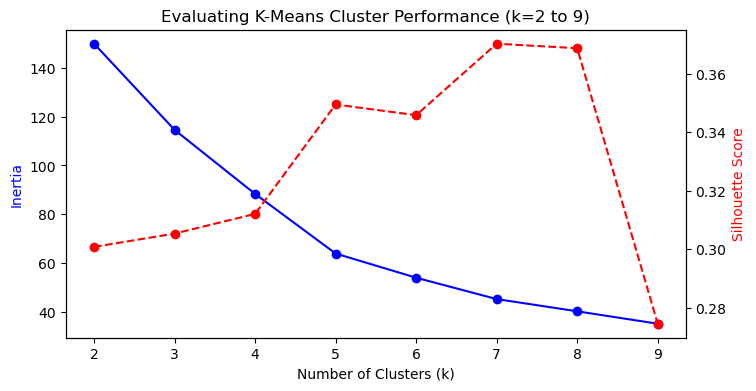

In [13]:
inertia = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_test.fit_predict(X_scaled)

    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))


# Plot Elbow Curve and Silhouette Scores
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(k_range, inertia, "bo-", label="Inertia (Elbow)")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color="b")

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, "ro--", label="Silhouette Score")
ax2.set_ylabel("Silhouette Score", color="r")

plt.title("Evaluating K-Means Cluster Performance (k=2 to 9)")
plt.show()


In [17]:
# 2. Define, Fit & Predict (Selecting optimal k = 7)

# Instantiate K-Means model with optimal cluster count
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)

# Fit model & assign cluster group numbers (0, 1, 2, 3,4) to each row
X_labeled["Cluster_Label"] = kmeans.fit_predict(X_scaled)
X_scaled["Cluster_Label"] = X_labeled["Cluster_Label"]

# 3. Model Study & Evaluation

final_silhouette = silhouette_score(
    X_scaled.drop(columns=["Cluster_Label"]), X_labeled["Cluster_Label"]
)
final_db_index = davies_bouldin_score(
    X_scaled.drop(columns=["Cluster_Label"]), X_labeled["Cluster_Label"]
)

print(f"Model Training Complete!")
print(f"Silhouette Score: {final_silhouette:.3f} (Higher is better, max 1.0)")
print(
    f"Davies-Bouldin Index: {final_db_index:.3f} (Lower is better, min 0.0)\n"
)

# Display sample of market rows with assigned group numbers
print("Sample Market Group Assignments:")
print(X_labeled[["mean_search_interest", "Cluster_Label"]].head(10))

Model Training Complete!
Silhouette Score: 0.359 (Higher is better, max 1.0)
Davies-Bouldin Index: 0.798 (Lower is better, min 0.0)

Sample Market Group Assignments:
                                mean_search_interest  Cluster_Label
country_name category                                              
Australia    Fashion_Beauty                  68.2825              1
             Fitness_Wearables               85.5775              1
             Nutrition_Diets                 73.6975              3
Brazil       Fashion_Beauty                  67.0675              1
             Fitness_Wearables               91.8900              4
             Nutrition_Diets                 60.6450              5
Canada       Fashion_Beauty                  69.1400              1
             Fitness_Wearables               77.4600              1
             Nutrition_Diets                 73.2375              3
China        Fashion_Beauty                  20.9750              0


In [18]:
X_labeled

mean_search_interest  \
country_name         category                                  
Australia            Fashion_Beauty                  68.2825   
                     Fitness_Wearables               85.5775   
                     Nutrition_Diets                 73.6975   
Brazil               Fashion_Beauty                  67.0675   
                     Fitness_Wearables               91.8900   
                     Nutrition_Diets                 60.6450   
Canada               Fashion_Beauty                  69.1400   
                     Fitness_Wearables               77.4600   
                     Nutrition_Diets                 73.2375   
China                Fashion_Beauty                  20.9750   
                     Fitness_Wearables               41.7450   
                     Nutrition_Diets                 31.5450   
France               Fashion_Beauty                  40.4125   
                     Fitness_Wearables               80.8900   
                     Nutrition_Diets                 40.5700   
India                Fashion_Beauty                  61.4800   
                     Fitness_Wearables               85.6625   
                     Nutrition_Diets                 92.5275   
Kenya                Fashion_Beauty                  74.2750   
                     Fitness_Wearables               88.8725   
                     Nutrition_Diets                 59.3525   
Mexico               Fashion_Beauty                  55.4125   
                     Fitness_Wearables               73.2525   
                     Nutrition_Diets                 32.5750   
Nigeria              Fashion_Beauty                  67.1450   
                     Fitness_Wearables               78.4075   
                     Nutrition_Diets                 60.1825   
Singapore            Fashion_Beauty                  41.3125   
                     Fitness_Wearables               72.6475   
                     Nutrition_Diets                 57.4925   
South_Africa         Fashion_Beauty                  72.0775   
                     Fitness_Wearables               81.9025   
                     Nutrition_Diets                 65.8525   
United_Arab_Emirates Fashion_Beauty                  75.3075   
                     Fitness_Wearables              100.4850   
                     Nutrition_Diets                 70.6975   
United_Kingdom       Fashion_Beauty                  64.7100   
                     Fitness_Wearables               91.6400   
                     Nutrition_Diets                 81.3400   
United_States        Fashion_Beauty                  45.4750   
                     Fitness_Wearables               57.4350   
                     Nutrition_Diets                 49.6375   

                                        mean_media_volume  \
country_name         category                               
Australia            Fashion_Beauty                  0.00   
                     Fitness_Wearables               0.25   
                     Nutrition_Diets              1517.25   
Brazil               Fashion_Beauty                  0.00   
                     Fitness_Wearables               1.00   
                     Nutrition_Diets              4114.50   
Canada               Fashion_Beauty                  0.75   
                     Fitness_Wearables               0.00   
                     Nutrition_Diets              3992.00   
China                Fashion_Beauty                  0.50   
                     Fitness_Wearables               0.00   
                     Nutrition_Diets             14209.25   
France               Fashion_Beauty                  1.75   
                     Fitness_Wearables               0.25   
                     Nutrition_Diets              7923.75   
India                Fashion_Beauty                  0.00   
                     Fitness_Wearables               0.00   
                     Nutrition_Diets             10211.25   
Ken

#### 📥 1.4 Saving groups & Study
- Save above group number added data to csv/excel
- group wise stats
    - Once group number added to row, then filter rows based on group number

In [19]:
# Compute Group-Wise Statistics (Market Profiles)

# Define the 6 core features to aggregate
core_features = ["mean_search_interest","mean_media_volume","mean_demand_to_hype_ratio","search_interest_trend_slope","mean_net_sentiment","mean_gdp_per_capita"]

# Calculate mean and std for each feature grouped by cluster number
group_stats = (X_labeled.groupby("Cluster_Label")[core_features].agg(["mean"]).round(2))
# Append total market count per group
group_stats[("Market_Count", "count")] = X_labeled.groupby("Cluster_Label")["mean_search_interest"].count()
print("\n--- Group-Wise Summary Statistics ---")
display(group_stats)



--- Group-Wise Summary Statistics ---


,mean_search_interest,mean_media_volume,mean_demand_to_hype_ratio,search_interest_trend_slope,mean_net_sentiment,mean_gdp_per_capita,Market_Count
,mean,mean,mean,mean,mean,mean,count
Cluster_Label,,,,,,,
0,41.79,1778.75,25.40,3.39,0.54,0.0,8
1,74.41,0.09,71.94,2.08,0.16,0.0,17
2,49.64,61235.50,0.00,-0.06,-1.61,0.0,1
3,80.20,3938.50,1.67,0.32,-0.90,0.0,4
4,90.79,0.25,84.78,15.94,-0.21,0.0,4
5,64.14,1268.12,0.51,10.56,-0.72,0.0,4
6,47.70,3068.75,0.50,1.63,-2.03,0.0,4


In [50]:
import json
import os
import pandas as pd
from dotenv import load_dotenv
from google import genai
from google.genai import errors, types
from pydantic import BaseModel, Field
from tenacity import (
    retry,
    retry_if_exception_type,
    stop_after_attempt,
    wait_exponential,
)

load_dotenv()
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))


# 1. Define Pydantic Schema
class ClusterItem(BaseModel):
    cluster_id: int = Field(
        description="The integer cluster label/ID (e.g., 0, 1, 2)."
    )
    cluster_name: str = Field(
        description="The recommended concise business name for this cluster."
    )


class ClusterAnalysisResponse(BaseModel):
    cluster_mappings: list[ClusterItem] = Field(
        description="List of mappings from cluster ID to business name."
    )
    detailed_analysis_markdown: str = Field(
        description="The complete structured analysis formatted in clean Markdown."
    )


# 2. Prompt
group_stats_html = group_stats.to_html()

prompt = f"""
You are a senior Data Scientist and Market Intelligence Analyst.
Analyze the following group statistics table generated from a market segmentation clustering model:

{group_stats_html}

Tasks:
1. Populate `cluster_mappings` with integer cluster_id values and recommended concise business names.
2. In `detailed_analysis_markdown`, provide the detailed breakdown:
   - SECTION 1: SUMMARY TABLE (Cluster_Label, Market_Count, Recommended Cluster Name, Key Insights Summary)
   - SECTION 2: DETAILED CLUSTER BREAKDOWN (Record Count, Metric trends, Business Interpretation, Business Use Case, Core Business Question Answered)
"""


# 3. Resilient Call with Exponential Retry
@retry(
    stop=stop_after_attempt(5),
    wait=wait_exponential(multiplier=2, min=2, max=30),
    retry=retry_if_exception_type((errors.ServerError, errors.APIError)),
    reraise=True,
)
def _call_model_structured(model_name: str, prompt_text: str):
    return client.models.generate_content(
        model=model_name,
        contents=prompt_text,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=ClusterAnalysisResponse,
        ),
    )


# 4. Fallback Handler
def generate_structured_analysis(prompt_text: str):
    candidate_models = [
        "gemini-3.8-flash",
        "gemini-3.5-flash",
        "gemini-2.5-flash",
    ]
    for model in candidate_models:
        try:
            return _call_model_structured(model, prompt_text)
        except (errors.ServerError, errors.APIError) as e:
            print(f"Model {model} failed: {e}. Switching model...")
    raise RuntimeError("All configured model candidates failed.")


# 5. Execute and extract dictionary
try:
    response = generate_structured_analysis(prompt)
    parsed_data = json.loads(response.text)

    # Extract dictionary
    cluster_names = {
        item["cluster_id"]: item["cluster_name"]
        for item in parsed_data["cluster_mappings"]
    }
    markdown_report = parsed_data["detailed_analysis_markdown"]

    # Map directly to DataFrame
    X_labeled["Cluster_Name"] = X_labeled["Cluster_Label"].map(cluster_names)

    print("Extracted Dictionary:", cluster_names)
    print("\nMarkdown Analysis:\n", markdown_report)

except Exception as e:
    print(f"Pipeline Execution Error: {e}")

Model gemini-3.8-flash failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}. Switching model...
Extracted Dictionary: {0: 'High-Sentiment Seed Markets', 1: 'Untapped High-Demand Niches', 2: 'Hyper-Hype PR Crisis Outlier', 3: 'Saturated High-Interest Arenas', 4: 'Explosive Grassroots Opportunities', 5: 'Fast-Growing High-Competition Waves', 6: 'Declining High-Risk Sectors'}

Markdown Analysis:
 # Market Segmentation & Clustering Analysis Report

## SECTION 1: SUMMARY TABLE

| Cluster_Label | Market_Count | Recommended Cluster Name | Key Insights Summary |
| :--- | :--- | :--- | :--- |
| **0** | 8 | High-Sentiment Seed Markets | Positive consumer sentiment, healthy organic demand-to-hype ratio, steady linear growth. Excellent for building initial brand affinity. |
| **1** | 17 | Untapped High-Demand Niches | Largest segment. Extremely high 

In [52]:
import json

# 1. Parse raw JSON text from Gemini response
parsed_data = json.loads(response.text)

# 2. Extract cluster mappings safely handling integer conversion
cluster_names = {
    int(item["cluster_id"]): str(item["cluster_name"])
    for item in parsed_data["cluster_mappings"]
}

# 3. Extract Markdown Report
markdown_report = parsed_data["detailed_analysis_markdown"]

# Print dictionary to verify keys and values
print("Constructed Cluster Names Dictionary:")
print(cluster_names)

# 4. Map directly to your DataFrame
X_labeled["Cluster_Label"] = X_labeled["Cluster_Label"].astype(int)  # Ensure integer type matches dict keys
X_labeled["Cluster_Name"] = X_labeled["Cluster_Label"].map(cluster_names)

# Inspect resulting DataFrame mapping
print("\nDataFrame Mapping Verification:")

Constructed Cluster Names Dictionary:
{0: 'High-Sentiment Seed Markets', 1: 'Untapped High-Demand Niches', 2: 'Hyper-Hype PR Crisis Outlier', 3: 'Saturated High-Interest Arenas', 4: 'Explosive Grassroots Opportunities', 5: 'Fast-Growing High-Competition Waves', 6: 'Declining High-Risk Sectors'}

DataFrame Mapping Verification:


In [53]:
X_labeled["Cluster_Name"] = X_labeled["Cluster_Label"].map(cluster_names)

In [54]:
X_labeled.head()

mean_search_interest  mean_media_volume  \
country_name category                                                     
Australia    Fashion_Beauty                  68.2825               0.00   
             Fitness_Wearables               85.5775               0.25   
             Nutrition_Diets                 73.6975            1517.25   
Brazil       Fashion_Beauty                  67.0675               0.00   
             Fitness_Wearables               91.8900               1.00   

                                mean_demand_to_hype_ratio  \
country_name category                                       
Australia    Fashion_Beauty                     68.282500   
             Fitness_Wearables                  74.847500   
             Nutrition_Diets                     0.129548   
Brazil       Fashion_Beauty                     67.067500   
             Fitness_Wearables                  67.850000   

                                search_interest_trend_slope  \
country_name category                                         
Australia    Fashion_Beauty                          -1.611   
             Fitness_Wearables                       -0.579   
             Nutrition_Diets                         -1.599   
Brazil       Fashion_Beauty                           6.533   
             Fitness_Wearables                       18.024   

                                mean_net_sentiment  mean_gdp_per_capita  \
country_name category                                                     
Australia    Fashion_Beauty                -0.1300                  0.0   
             Fitness_Wearables              0.1400                  0.0   
             Nutrition_Diets               -1.0900                  0.0   
Brazil       Fashion_Beauty                -0.1300                  0.0   
             Fitness_Wearables             -0.4325                  0.0   

                                Cluster_Label  \
country_name category                           
Australia    Fashion_Beauty                 1   
             Fitness_Wearables              1   
             Nutrition_Diets                3   
Brazil       Fashion_Beauty                 1   
             Fitness_Wearables              4   

                                                      Cluster_Name  
country_name category                                               
Australia    Fashion_Beauty            Untapped High-Demand Niches  
             Fitness_Wearables         Untapped High-Demand Niches  
             Nutrition_Diets        Saturated High-Interest Arenas  
Brazil       Fashion_Beauty            Untapped High-Demand Niches  
             Fitness_Wearables  Explosive Grassroots Opportunities

In [56]:
import io
import os
import pandas as pd
import boto3
from botocore.config import Config
from dotenv import load_dotenv

# ------------------------------------------------------------------
# 1. Load Environment Variables & Configure R2 Client
# ------------------------------------------------------------------
load_dotenv(override=True)

R2_ACCOUNT_ID = os.getenv("R2_ACCOUNT_ID", "").strip()
R2_ACCESS_KEY_ID = os.getenv("R2_ACCESS_KEY_ID", "").strip()
R2_SECRET_ACCESS_KEY = os.getenv("R2_SECRET_ACCESS_KEY", "").strip()
R2_BUCKET_NAME = os.getenv("R2_BUCKET_NAME", "").strip().strip("/")

if not all([R2_ACCOUNT_ID, R2_ACCESS_KEY_ID, R2_SECRET_ACCESS_KEY, R2_BUCKET_NAME]):
    raise ValueError("❌ Missing R2 environment variables in .env file.")

endpoint_url = f"https://{R2_ACCOUNT_ID}.r2.cloudflarestorage.com"

s3_client = boto3.client(
    "s3",
    endpoint_url=endpoint_url,
    aws_access_key_id=R2_ACCESS_KEY_ID,
    aws_secret_access_key=R2_SECRET_ACCESS_KEY,
    region_name="us-east-1",
    config=Config(signature_version="s3v4", s3={"addressing_style": "path"})
)

# ------------------------------------------------------------------
# 2. Upload CSV DataFrame to R2
# ------------------------------------------------------------------
def upload_df_csv_to_r2(df: pd.DataFrame, r2_key: str) -> bool:
    """Converts a pandas DataFrame to CSV bytes and uploads directly to R2."""
    clean_key = r2_key.lstrip("/")
    try:
        print(f"⏳ Encoding DataFrame to CSV bytes for '{clean_key}'...", end="", flush=True)
        csv_buffer = io.StringIO()
        df.to_csv(csv_buffer, index=False)
        payload_bytes = csv_buffer.getvalue().encode("utf-8")
        size_kb = len(payload_bytes) / 1024
        print(f" ✅ Done ({size_kb:.2f} KB)")

        print(f"⏳ Uploading to R2 bucket '{R2_BUCKET_NAME}'...", end="", flush=True)
        response = s3_client.put_object(
            Bucket=R2_BUCKET_NAME,
            Key=clean_key,
            Body=payload_bytes,
            ContentType="text/csv"
        )
        
        status_code = response.get("ResponseMetadata", {}).get("HTTPStatusCode")
        if status_code == 200:
            print(f" ✅ Success! (HTTP 200) -> {R2_BUCKET_NAME}/{clean_key}")
            return True
        else:
            print(f" ⚠️ Unexpected HTTP status: {status_code}")
            return False
    except Exception as e:
        print(f"\n❌ Upload failed for '{clean_key}': {e}")
        return False

# ------------------------------------------------------------------
# 3. Upload Markdown Report to R2
# ------------------------------------------------------------------
def upload_markdown_to_r2(markdown_text: str, r2_key: str) -> bool:
    """Uploads markdown text directly to R2 as a .md file."""
    clean_key = r2_key.lstrip("/")
    try:
        print(f"⏳ Uploading Markdown report to R2 bucket '{R2_BUCKET_NAME}'...", end="", flush=True)
        response = s3_client.put_object(
            Bucket=R2_BUCKET_NAME,
            Key=clean_key,
            Body=markdown_text.encode("utf-8"),
            ContentType="text/markdown"
        )
        status_code = response.get("ResponseMetadata", {}).get("HTTPStatusCode")
        if status_code == 200:
            print(f" ✅ Success! (HTTP 200) -> {R2_BUCKET_NAME}/{clean_key}")
            return True
        else:
            print(f" ⚠️ Unexpected HTTP status: {status_code}")
            return False
    except Exception as e:
        print(f"\n❌ Upload failed for '{clean_key}': {e}")
        return False

# ------------------------------------------------------------------
# 4. Reset Index & Upload Both CSV and Markdown
# ------------------------------------------------------------------
market_segmentation_df = X_labeled.reset_index()

# CSV upload
csv_file_name = "4_weeks_market_segmentation.csv"
csv_r2_key = f"data/processed/{csv_file_name}"
upload_df_csv_to_r2(market_segmentation_df, csv_r2_key)

# Markdown upload
md_file_name = "4_weeks_market_segmentation.md"
md_r2_key = f"reports/{md_file_name}"
upload_markdown_to_r2(markdown_report, md_r2_key)

print("\n🎉 4_Weeks_Market segmentation dataset and Markdown report uploaded directly to Cloudflare R2!")


⏳ Encoding DataFrame to CSV bytes for 'data/processed/4_weeks_market_segmentation.csv'... ✅ Done (4.88 KB)
⏳ Uploading to R2 bucket 'marketing-intelligence'... ✅ Success! (HTTP 200) -> marketing-intelligence/data/processed/4_weeks_market_segmentation.csv
⏳ Uploading Markdown report to R2 bucket 'marketing-intelligence'... ✅ Success! (HTTP 200) -> marketing-intelligence/reports/4_weeks_market_segmentation.md

🎉 4_Weeks_Market segmentation dataset and Markdown report uploaded directly to Cloudflare R2!


## 📂 Saved Model outputs to Cloud flare r2